<a href="https://colab.research.google.com/github/Addispa/Addispa/blob/main/pd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from numpy.typing import NDArray
import pandas as pd
import spacy
from scipy.sparse import issparse
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from typing import Text,List,Iterator,Iterable,Union, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
nltk.download("stopwords")
nltk.download("punkt")
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
nltk.download('wordnet')
import string
import warnings
warnings.filterwarnings("ignore")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
#from google.colab import drive
#drive.mount('/content/multimodal_train.tsv')

In [ ]:
data = pd.read_csv("/content/fake-news-data.csv")

In [ ]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


<Axes: title={'center': 'posts related to fake news'}, xlabel='fake_or_factual'>

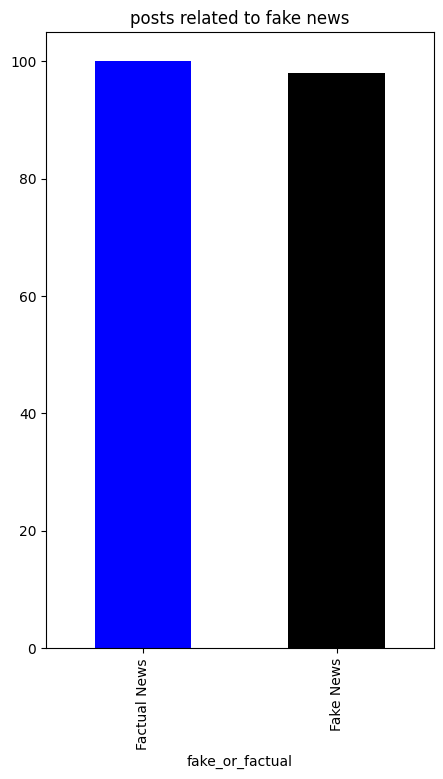

In [ ]:
data["fake_or_factual"].value_counts().plot(kind="bar",figsize=(5,8),color=["blue","black"],title="posts related to fake news")

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
Fake_news = data[data["fake_or_factual"] == "FAKE"]
Real_news = data[data["fake_or_factual"] == "REAL"]

In [ ]:
fake_spacydocs = list(nlp.pipe(Fake_news["text"]))
real_spacydocs = list(nlp.pipe(Real_news["text"]))

In [ ]:
def extract_token_tags(doc:spacy.tokens.doc.Doc):
  return [(i.text,i.ent_type_,i.pos_) for i in doc]

In [ ]:
fake_tagsdf = []
columns = ["token","ner_tag","pos_tag"]
for ix, doc in enumerate(fake_spacydocs):
  tags = extract_token_tags(doc)
  #tags = pd.DataFrame(tags,columns=columns)
  tags = pd.DataFrame(tags)
  tags.columns = columns
  tags["doc_id"] = ix
  fake_tagsdf.append(tags)

In [ ]:
print (fake_tagsdf)

[]
